# Exploratory Data Analysis (EDA)
The objective of this notebook is to analyze sales performance, customer behavior, product performance, and business trends using the feature-engineered retail dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Retail_Feature_Engineered.csv")

In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [5]:
# Analysis 1 — Monthly Revenue Trend
monthly_sales = (
    df.groupby("MonthName")["TotalAmount"]
      .sum()
)
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = monthly_sales.reindex(month_order)

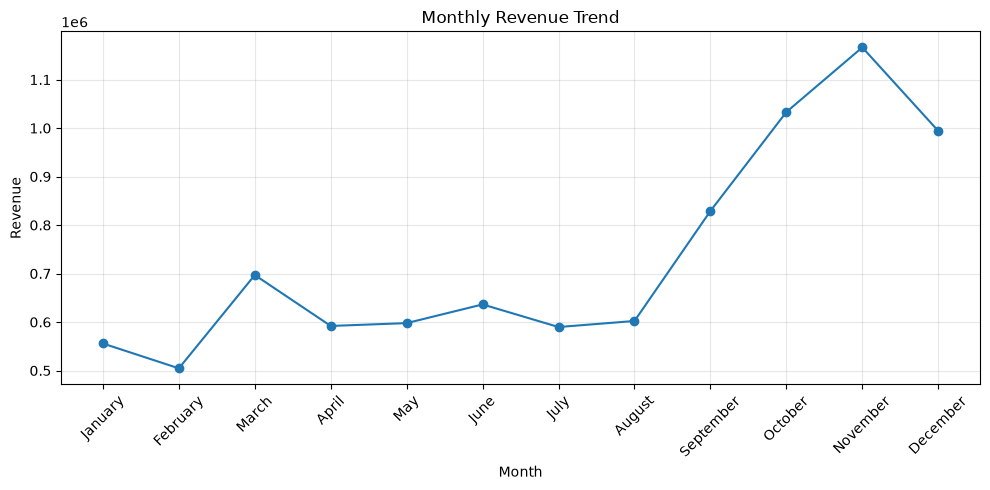

In [6]:
plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Business Insight

- Revenue changes across different months.
- Peak sales months indicate seasonal demand.
- Business can plan promotions and inventory accordingly.

In [7]:
# Analysis 2 — Top 10 Products by Revenue
top_products = (
    df[
        (~df["Description"].isin(["Manual","POSTAGE"])) &
        (df["Description"] != "")
    ]
    .groupby("Description")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

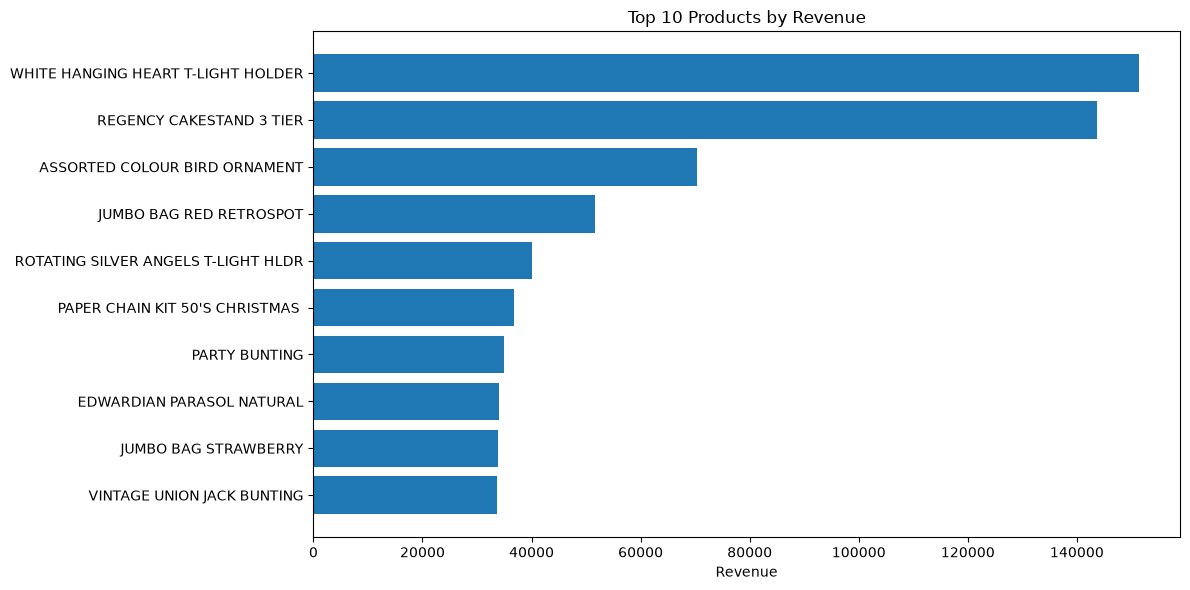

In [8]:
plt.figure(figsize=(12,6))

plt.barh(top_products.index[::-1],
         top_products.values[::-1])

plt.title("Top 10 Products by Revenue")

plt.xlabel("Revenue")

plt.tight_layout()

plt.show()

- White Hanging Heart T-Light Holder generated the highest revenue.
- High-performing products should receive priority in inventory planning and marketing campaigns.

In [9]:
# Analysis 3 — Country-wise Revenue
country_sales = (
    df.groupby("Country")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

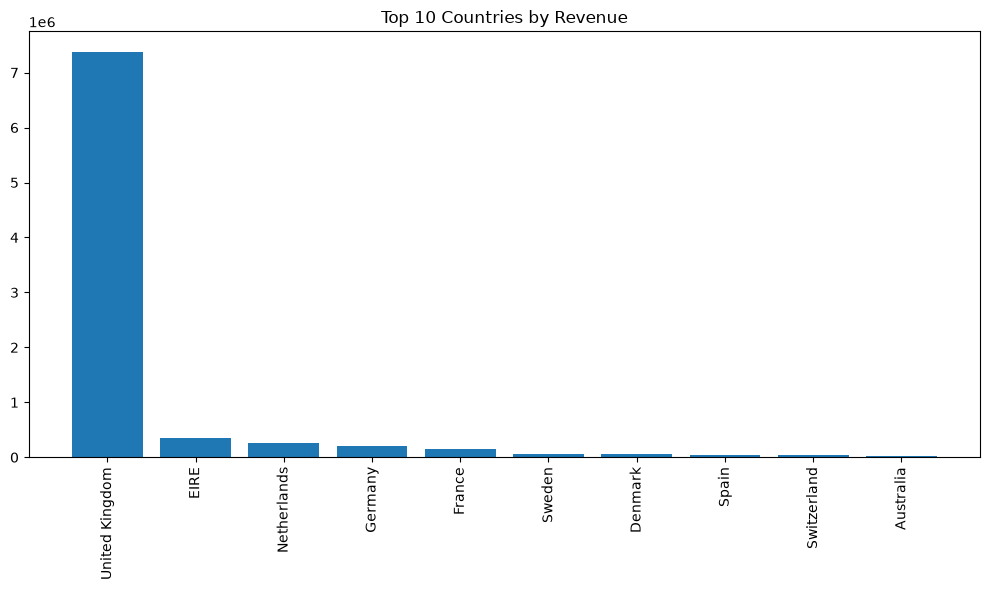

In [10]:
plt.figure(figsize=(10,6))

plt.bar(country_sales.index,
        country_sales.values)

plt.xticks(rotation=90)

plt.title("Top 10 Countries by Revenue")

plt.tight_layout()

plt.show()

In [11]:
# Analysis 4 — Top Customers
top_customers = (
    df.groupby("Customer ID")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

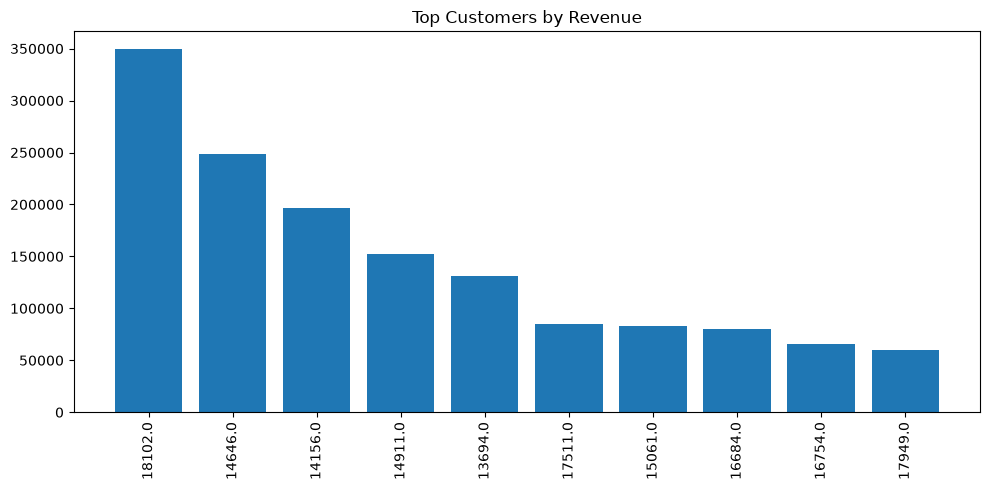

In [12]:
plt.figure(figsize=(10,5))

plt.bar(top_customers.index.astype(str),
        top_customers.values)

plt.xticks(rotation=90)

plt.title("Top Customers by Revenue")

plt.tight_layout()

plt.show()

In [17]:
# Analysis 5 — Weekday Revenue
weekday_sales = (
    df.groupby("Weekday")["TotalAmount"]
      .sum()
)
     

In [14]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = weekday_sales.reindex(weekday_order)

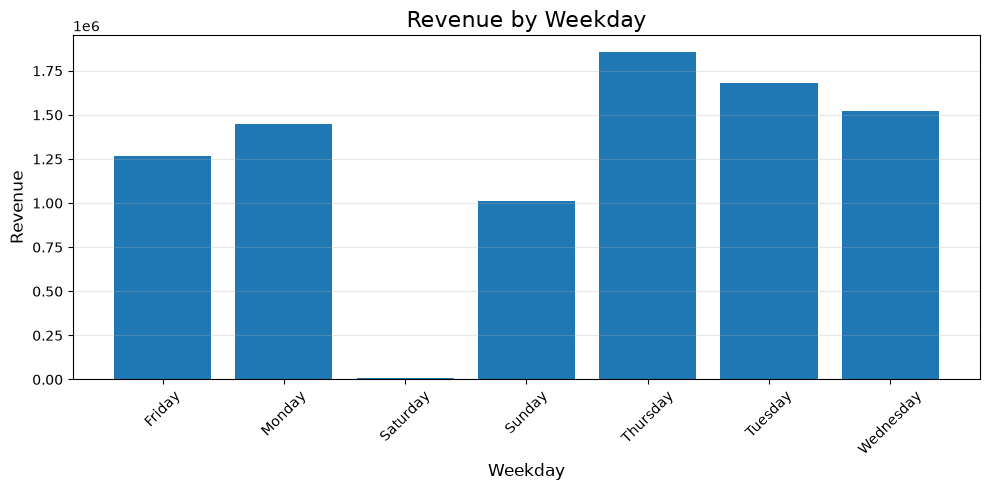

In [18]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_sales.index,
    weekday_sales.values
)

plt.title("Revenue by Weekday", fontsize=16)
plt.xlabel("Weekday", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

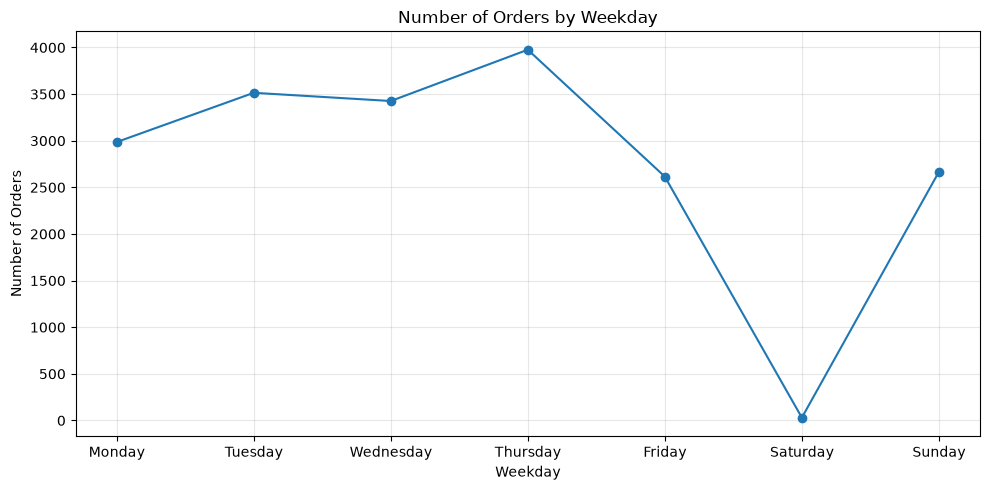

In [19]:
weekday_orders = df.groupby("Weekday")["Invoice"].nunique()
weekday_orders = weekday_orders.reindex(weekday_order)

plt.figure(figsize=(10,5))

plt.plot(
    weekday_orders.index,
    weekday_orders.values,
    marker="o"
)

plt.title("Number of Orders by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Orders")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Analysis 6 — Hour-wise Revenue
hour_sales = (
    df.groupby("Hour")["TotalAmount"]
      .sum()
)

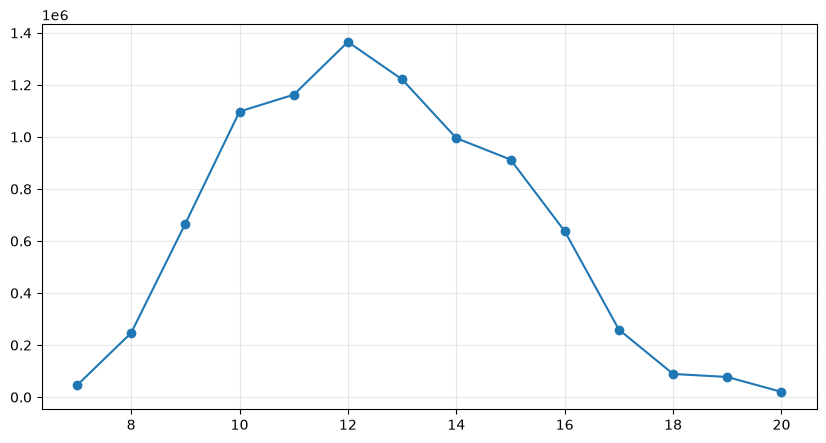

In [21]:
plt.figure(figsize=(10,5))

plt.plot(hour_sales.index,
         hour_sales.values,
         marker="o")

plt.grid(alpha=0.3)

plt.show()

In [22]:
# Analysis 7 — Average Order Value
aov = df.groupby("Invoice")["TotalAmount"].sum().mean()

print("Average Order Value :", round(aov,2))

Average Order Value : 457.93


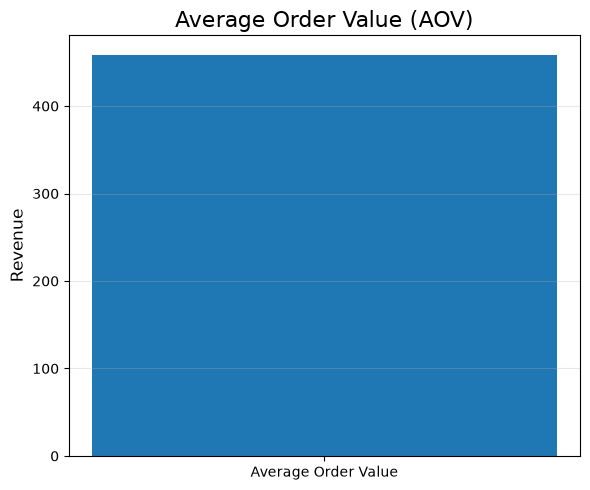

In [23]:
plt.figure(figsize=(6,5))

plt.bar(
    ["Average Order Value"],
    [aov]
)

plt.title("Average Order Value (AOV)", fontsize=16)
plt.ylabel("Revenue", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Business Insight

- Average Order Value (AOV) represents the average revenue generated per transaction.
- Increasing AOV through cross-selling and bundled offers can improve overall revenue.

In [24]:
# Count unique orders
monthly_orders = df.groupby("MonthName")["Invoice"].nunique()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_orders = monthly_orders.reindex(month_order)

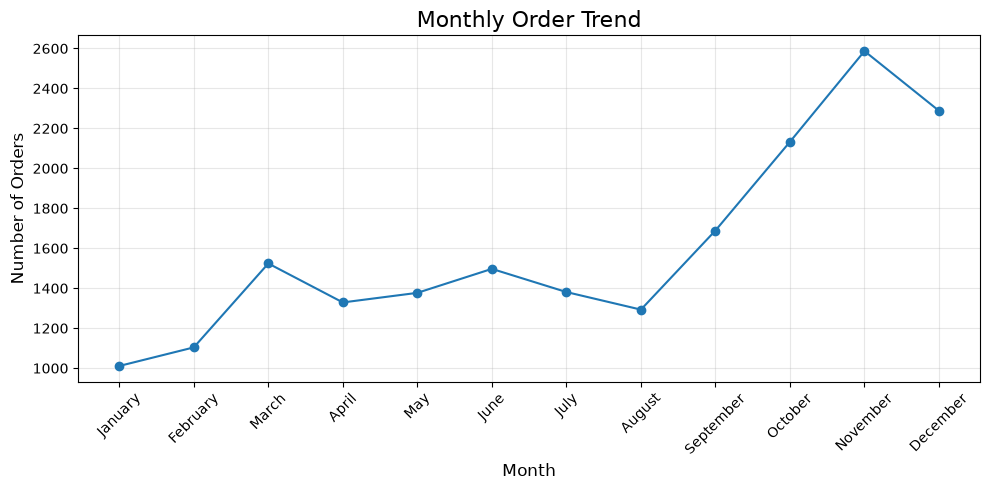

In [25]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker="o"
)

plt.title("Monthly Order Trend", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Business Insight

- The number of customer orders changes across different months.
- High-order months indicate increased customer demand and seasonal purchasing patterns.
- Businesses can optimize inventory and promotional campaigns based on monthly order trends.

# EDA Summary

The analysis identified:

- Monthly Sales Trend
- Top Products
- Country-wise Revenue
- Top Customers
- Weekday Sales
- Hourly Sales
- Average Order Value
- Monthly Orders

These insights help support inventory planning, marketing strategies, and business decision-making.